# Apartment Rents
In this notebook, we build a regression model to predict apartment rental prices. We try to fit a Linear Regression model, but we fail to verify the normality hypothesis for the residuals and consider a logarithmic version and a XGBRegressor model instead.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')

import warnings
warnings.filterwarnings('ignore')

The raw data is divided into two csv files, with nearly 100.000 entries in `df1` and 10.000 in `df2`, and stored in the `brz_path`, representing the bronze layer in the medallion architecure. Later, we will define the silver layer to store the processed dataframe. For now, we read them both and use `pd.concat` to unify them.

In [ ]:
brz_path = 'bronze'
df1 = pd.read_csv(f'{brz_path}/dataset1.csv', sep=';', encoding='cp1252')
df2 = pd.read_csv(f'{brz_path}/dataset2.csv', sep=';', encoding='cp1252')

df = pd.concat([df1, df2], ignore_index=True, axis=0)
df

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,...,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,...,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109487,5630240092,housing/rent/apartment,Five BR 5407 Abbott Place - Abbott,This unit is located at 5407 Abbott Place - Ab...,NaN,4.0,5.0,USD,No,Thumbnail,...,"$6,000",Monthly,6300,5407 Abbott Place Abbott,Edina,MN,44.9000,-93.3233,RentLingo,1575112975
109488,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,USD,No,Thumbnail,...,"$25,000",Monthly,8716,256 Las Entradas,Montecito,CA,34.4331,-119.6331,RentLingo,1577360419
109489,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,USD,No,Thumbnail,...,"$11,000",Monthly,11318,9908 Bentcross Dr,Potomac,MD,39.0287,-77.2409,RentLingo,1577360560
109490,5668662559,housing/rent/apartment,One BR in New York NY 10069,"Monthly Rent$4,605 -to $4,790AmenitiesThe Aldy...","Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,USD,No,Thumbnail,...,"$4,790",Monthly,40000,NaN,New York,NY,40.7716,-73.9876,Listanza,1577362186


We observe null values in several columns. They will be treated, individually, in the corresponding sections.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109492 entries, 0 to 109491
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             109492 non-null  int64  
 1   category       109492 non-null  object 
 2   title          109492 non-null  object 
 3   body           109492 non-null  object 
 4   amenities      89899 non-null   object 
 5   bathrooms      109395 non-null  float64
 6   bedrooms       109361 non-null  float64
 7   currency       109492 non-null  object 
 8   fee            109492 non-null  object 
 9   has_photo      109492 non-null  object 
 10  pets_allowed   44905 non-null   object 
 11  price          109491 non-null  float64
 12  price_display  109491 non-null  object 
 13  price_type     109492 non-null  object 
 14  square_feet    109492 non-null  int64  
 15  address        14616 non-null   object 
 16  cityname       109113 non-null  object 
 17  state          109113 non-nul

As `price` is our target, we first select relevant columns to analyse the dataframe.

In [3]:
keep_cols = [
    'id', 'amenities',
    'bathrooms', 'bedrooms',
    'pets_allowed', 'price',
    'price_type', 'square_feet',
    'cityname', 'currency',
    'category', 'state'
]

df = df[keep_cols].copy()
df.head()

,id,amenities,bathrooms,bedrooms,pets_allowed,price,price_type,square_feet,cityname,currency,category,state
0,5668640009,NaN,1.0,1.0,Cats,2195.0,Monthly,542,Redondo Beach,USD,housing/rent/apartment,CA
1,5668639818,NaN,1.5,3.0,"Cats,Dogs",1250.0,Monthly,1500,Newport News,USD,housing/rent/apartment,VA
2,5668639686,NaN,2.0,3.0,NaN,1395.0,Monthly,1650,Raleigh,USD,housing/rent/apartment,NC
3,5668639659,NaN,1.0,2.0,"Cats,Dogs",1600.0,Monthly,820,Vacaville,USD,housing/rent/apartment,CA
4,5668639374,NaN,1.0,1.0,"Cats,Dogs",975.0,Monthly,624,Albuquerque,USD,housing/rent/apartment,NM


## EDA

Regarding null values, we have:

In [4]:
df.isnull().sum()

id                  0
amenities       19593
bathrooms          97
bedrooms          131
pets_allowed    64587
price               1
price_type          0
square_feet         0
cityname          379
currency            0
category            0
state             379
dtype: int64

However, not all of them are problematic since, from the dataset, we notice that some refer to its absence in the apartment: for instance, a null value in the `amenities` column refer to an apartment with no amenities, and likewise for `pets_allowed`. (We actually have no method to distinguish the *absence* missing from the *error* missing and will assume that all of them refer to the former.)

For features where that is not the case, as in `cityname` and `state`, a treatment will be applied.

We observe duplicate values, to be dropped right away.

In [5]:
print(f'Dataset length: {len(df)}')
print(f'Dataset length without duplicates: {len(df.drop_duplicates(subset=['id']))}')

Dataset length: 109492
Dataset length without duplicates: 99425


In [4]:
df = df.drop_duplicates(subset=['id']).copy()

### Currency
Before starting, it is important to make sure that all prices are in the same currency. For that, let us check its unique values.

In [7]:
df['currency'].unique()

array(['USD'], dtype=object)

As it is the case, we no longer need this variable and it will be dropped.

In [5]:
df = df.drop(columns=['currency'])

### Category
We will consider only housing/rent/apartment in this project, since other values are too small to be considered and treated separately. Therefore, we filter the `category` column and drop it afterwards.

In [9]:
df['category'].value_counts()

category
housing/rent/apartment            99364
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/short_term               4
housing/rent/home                     4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64

In [6]:
df = df.query('category == "housing/rent/apartment"')\
    .drop(columns=['category'])\
    .copy()

### Price Type
To ensure that all prices are in the same unit, in the same way as currency, let us check if we have different price types.

In [11]:
df['price_type'].unique()

array(['Monthly', 'Weekly', 'Monthly|Weekly'], dtype=object)

In [12]:
df['price_type'].value_counts()

price_type
Monthly           99360
Weekly                3
Monthly|Weekly        1
Name: count, dtype: int64

In [7]:
df.query('price_type != "Monthly"')

,id,amenities,bathrooms,bedrooms,pets_allowed,price,price_type,square_feet,cityname,state
6729,5659276240,"AC,Basketball,Cable or Satellite,Gym,Internet ...",1.0,1.0,"Cats,Dogs",1560.0,Weekly,200,New Bern,NC
7245,5625835116,"Cable or Satellite,Pool,Refrigerator,Storage,TV",NaN,NaN,"Cats,Dogs",275.0,Monthly|Weekly,300,Lakeland,FL
49908,5518370229,"AC,Fireplace,Patio/Deck,Pool,TV",4.0,4.0,NaN,8500.0,Weekly,3600,East Hampton,NY
83395,5161839760,Elevator,2.5,2.0,NaN,850.0,Weekly,2326,New York,NY


As there are very few entries with `price_type != "Monthly"` and some of them we are unsure of its real values (we could, for instance, multiply the Weekly values by 4 to convert them into Monthly, but 8500 and 1560 is too high already on a weekly basis and Monthly|Weekly is ambiguous), we shall drop them all and keep only Monthly values.

In [7]:
df = df.query('price_type == "Monthly"')\
    .drop(columns=['price_type'])\
    .copy()

With the certainty that we now have all prices in the same unit and scale, we start our EDA.

### Sq Feet to Sq Meter
We first consider converting the square feet column to square meters, as it is a more standard unit.

In [8]:
SQ_FT_TO_SQ_M = 0.092903
df['m2'] = df['square_feet'] * SQ_FT_TO_SQ_M

### Bathrooms
We have missing values in this feature. To treat it, we will consider imputation with the `KNNImputer`, but, first, we must deal with the outliers. Note: despite using the same technique to idenfiy outliers, we consider different $s$ values (the standard deviation from the mean factor) for each, in order to be more (higher $s$) or less (smaller $s$) conservative about the corresponding feature. A more (less) conservative approach means that we are keeping more (less) data in the dataset. For `bathrooms`, we use $s = 3$ to remove only apartments with more than, or equal to, 5 bathrooms.

In [9]:
c = 'bathrooms'
q1 = df[c].quantile(.25)
q3 = df[c].quantile(.75)
iqr = q3 - q1

s = 3
l_bound = q1 - s * iqr
u_bound = q3 + s * iqr

print(f'Lower bound: {l_bound}')
print(f'Upper bound: {u_bound}')

bath_outliers = (df[c] < l_bound) | (df[c] > u_bound)
df[bath_outliers]

Lower bound: -2.0
Upper bound: 5.0


,id,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,cityname,state,m2
477,5668628928,NaN,7.0,7.0,NaN,9000.0,4355,Bloomington,IN,404.592565
3180,5668636280,NaN,7.0,7.0,"Cats,Dogs",7700.0,3000,Providence,RI,278.709000
3487,5668640983,NaN,8.0,6.0,NaN,25000.0,8716,Montecito,CA,809.742548
3907,5668643292,NaN,8.5,6.0,NaN,11000.0,11318,Potomac,MD,1051.476154
4356,5668628031,NaN,6.0,5.0,"Cats,Dogs",9500.0,4812,Las Vegas,NV,447.049236
5902,5664598289,NaN,5.5,4.0,NaN,6500.0,3117,Coronado,CA,289.578651
14400,5509150943,"Dishwasher,Elevator,Fireplace,Hot Tub,View,Was...",5.5,5.0,NaN,30000.0,5872,Snowmass Village,CO,545.526416
15970,5508883814,"Cable or Satellite,Elevator,Pool,TV",6.0,5.0,NaN,14500.0,4362,Los Angeles,CA,405.242886
16713,5509116386,"AC,Elevator,Fireplace,Parking,Pool,Storage,Woo...",6.0,5.0,NaN,4500.0,4911,Hammonton,NJ,456.246633
31529,5508857375,"Fireplace,Parking,Playground,Pool",5.5,5.0,NaN,9800.0,3122,Los Angeles,CA,290.043166


In [10]:
df = df[~bath_outliers].copy()

We notice half-integer values in this column. We thus transform it to the lowest integer, such that 3.5 will be converted into 3.

In [11]:
c = 'bathrooms'

df[c] = df[c].apply(lambda x: np.floor(x) if pd.notnull(x) else x)

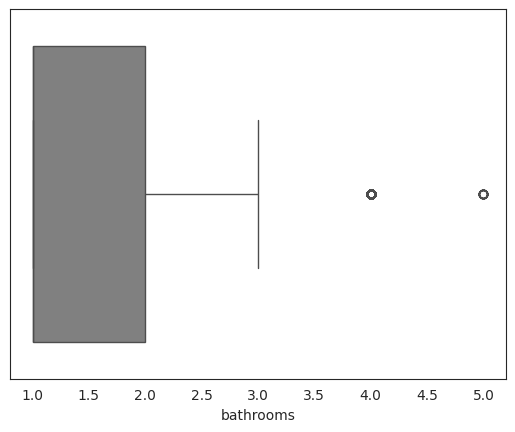

In [24]:
sns.boxplot(
    data=df,
    x=c,
    color='grey'
);

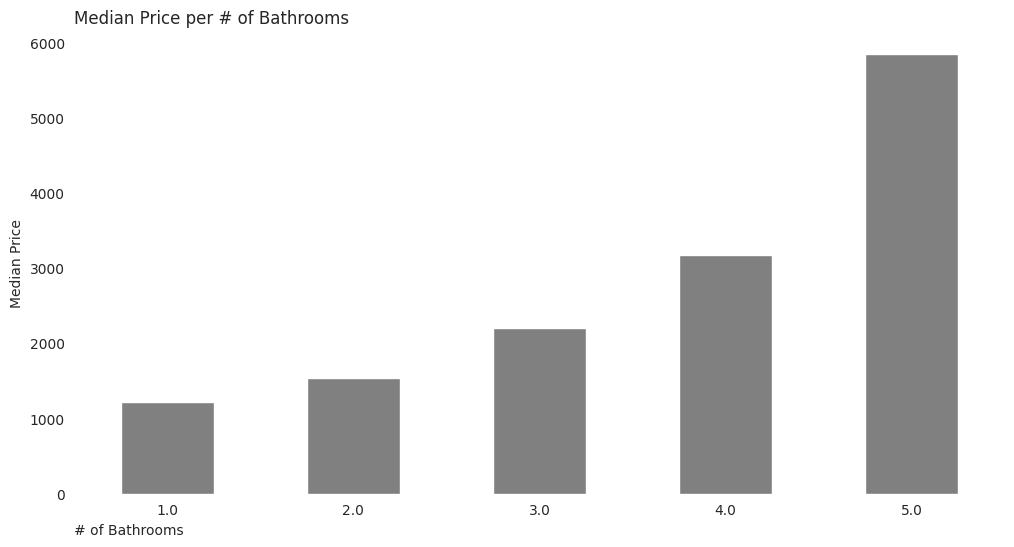

In [25]:
df[[c, 'price']].groupby(c).median().plot.bar(
    figsize=(12, 6),
    color='grey'
)
plt.title(f'Median Price per # of {c.title()}', loc='left', fontsize=12)
plt.xlabel(f'# of {c.title()}', loc='left', fontsize=10)
plt.ylabel('Median Price', fontsize=10)
plt.legend().remove()
plt.xticks(rotation=0)
plt.box(False)

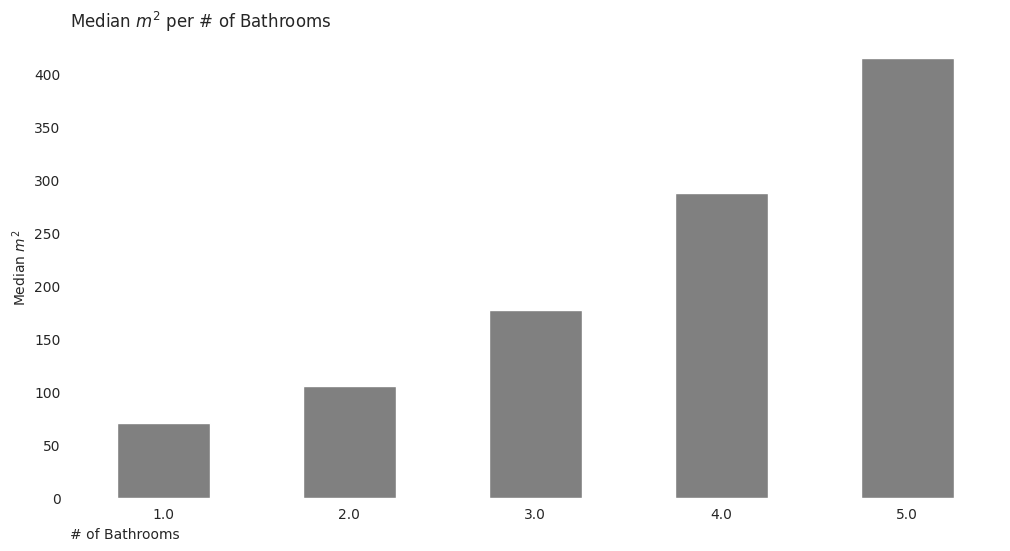

In [12]:
df[[c, 'm2']].groupby(c).median().plot.bar(
    figsize=(12, 6),
    color='grey'
)
plt.title(f'Median $m^2$ per # of {c.title()}', loc='left', fontsize=12)
plt.xlabel(f'# of {c.title()}', loc='left', fontsize=10)
plt.ylabel('Median $m^2$', fontsize=10)
plt.legend().remove()
plt.xticks(rotation=0)
plt.box(False)

#### KNN Imputer
$K$-Nearest Neighbor (KNN) imputation is a multivariate type of imputation since multiple features (columns) are used to predict missing values. It works by finding the nearest neighbors (rows) that have similar patterns to the row with missing data, that is, it fills in missing data by replacing each missing value with a value derived from similar cases within the entire dataset. The nearest neighbors are determined by a distance metric like Euclidean distance and the value is then assigned as an average, weighted by their proximity (the closer the neighbor, the more influence it has on the imputed value).

Because this method relies on other observations, we need to prevent data leakage by evaluating it after the train test splitting. Additionally, since it uses the Euclidean distance, we need to apply the `StandarScaler` transformation on all numerical variables before the imputation. Therefore, we will leave this column as it is for now and return to it when we split the data.

### Bedrooms
We also have outliers in this feature. They are treated in the same way as before, with the same $s$ value, thus removing apartments with more than, or equal to, 5 bedrooms.

In [12]:
c = 'bedrooms'
q1 = df[c].quantile(.25)
q3 = df[c].quantile(.75)
iqr = q3 - q1

s = 3
l_bound = q1 - s * iqr
u_bound = q3 + s * iqr

print(f'Lower bound: {l_bound}')
print(f'Upper bound: {u_bound}')

bed_outliers = (df[c] < l_bound) | (df[c] > u_bound)
df[bed_outliers].head()

Lower bound: -2.0
Upper bound: 5.0


,id,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,cityname,state,m2
630,5668616326,"Dishwasher,Fireplace,Garbage Disposal,Parking,...",4.0,8.0,NaN,8345.0,4900,Madison,WI,455.224700
1884,5668638871,NaN,3.0,6.0,"Cats,Dogs",2495.0,3369,Saint George,UT,312.990207
1948,5668626375,NaN,2.0,6.0,"Cats,Dogs",4430.0,2995,Ann Arbor,MI,278.244485
2281,5668629518,NaN,4.0,6.0,NaN,7600.0,4733,San Diego,CA,439.709899
2293,5668627243,"Dishwasher,Parking,Refrigerator",5.0,9.0,NaN,3195.0,4000,Kalamazoo,MI,371.612000


In [13]:
df = df[~bed_outliers].copy()

In fact, we observe apartments with 0 bedrooms. We discard them as they may be wrongly inputed data.

In [14]:
df = df.query('bedrooms != 0')

#### KNN Imputer

Likewise for the missing values: `KNNImputer`, which will be returned to later. For now, we simply convert the half-integer values to integer.

In [15]:
c = 'bedrooms'

df[c] = df[c].apply(lambda x: np.floor(x) if pd.notnull(x) else x)

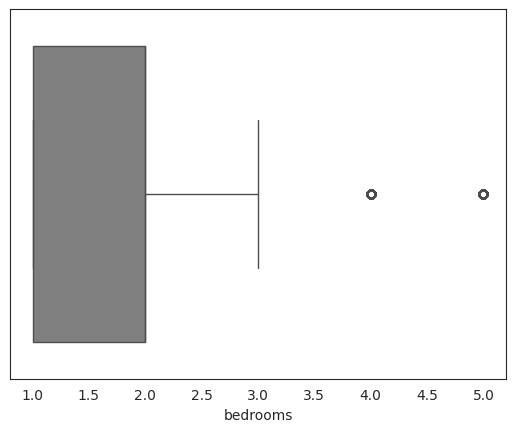

In [15]:
sns.boxplot(
    data=df,
    x=c,
    color='grey'
);

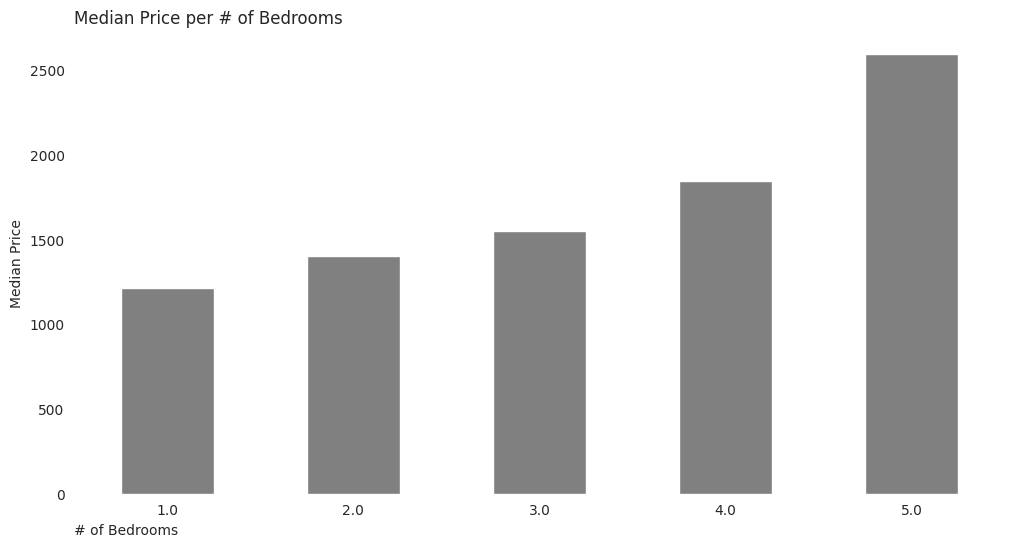

In [34]:
df[[c, 'price']].groupby(c).median().plot.bar(
    figsize=(12, 6),
    color='grey'
)
plt.title(f'Median Price per # of {c.title()}', loc='left', fontsize=12)
plt.xlabel(f'# of {c.title()}', loc='left', fontsize=10)
plt.ylabel('Median Price', fontsize=10)
plt.legend().remove()
plt.xticks(rotation=0)
plt.box(False)

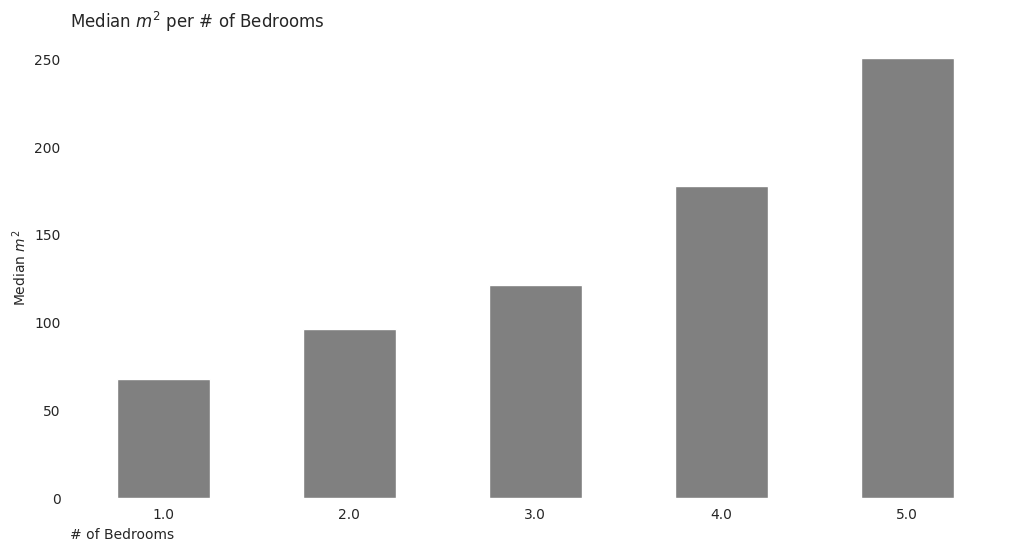

In [19]:
df[[c, 'm2']].groupby(c).median().plot.bar(
    figsize=(12, 6),
    color='grey'
)
plt.title(f'Median $m^2$ per # of {c.title()}', loc='left', fontsize=12)
plt.xlabel(f'# of {c.title()}', loc='left', fontsize=10)
plt.ylabel('Median $m^2$', fontsize=10)
plt.legend().remove()
plt.xticks(rotation=0)
plt.box(False)

### Amenities
In this case, we understand the missings as *absence* missings, such that we create another column to consider the number of amenities in the apartment and denote it as `n_amenities`. We then fill the missing values with the null string, apply the `split` method followed by the `len` method to count the number of entries in the now converted list of amenities.

In [16]:
df['n_amenities'] = df['amenities']\
    .fillna('')\
    .str.split(',')\
    .apply(lambda x: len(x) if x != [''] else 0)

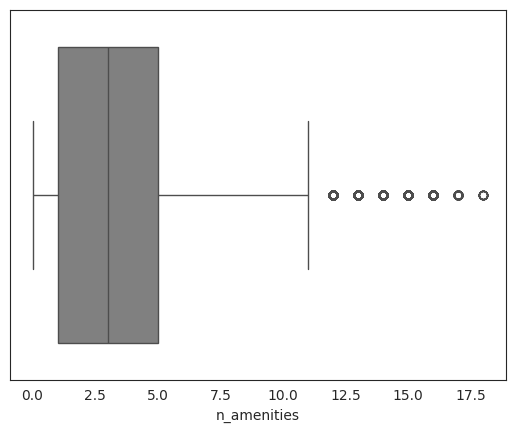

In [ ]:
sns.boxplot(
    data=df,
    x='n_amenities',
    color='grey'
);

We now observe outliers in `n_amenities` and treat it in a more consertative way, with a slightly higher $s$, leaving more apartments in the dataset. Particularly for this feature, we understand higher number of amenities as real cases (apartments with more comfort) and not as distortions from reality or errors.

In [17]:
c = 'n_amenities'
q1 = df[c].quantile(.25)
q3 = df[c].quantile(.75)
iqr = q3 - q1

s = 3
l_bound = q1 - s * iqr
u_bound = q3 + s * iqr

print(f'Lower bound: {l_bound}')
print(f'Upper bound: {u_bound}')

amen_outliers = (df[c] < l_bound) | (df[c] > u_bound)
df[amen_outliers]

Lower bound: -11.0
Upper bound: 17.0


,id,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,cityname,state,m2,n_amenities
7697,5508696001,"AC,Cable or Satellite,Clubhouse,Dishwasher,Fir...",2.0,3.0,NaN,1420.0,1155,Las Vegas,NV,107.302965,18
15675,5509054604,"AC,Clubhouse,Dishwasher,Doorman,Elevator,Firep...",1.0,1.0,"Cats,Dogs",1352.0,800,Raleigh,NC,74.322400,18
57284,5197804274,"AC,Cable or Satellite,Clubhouse,Dishwasher,Ele...",2.0,2.0,NaN,1519.0,1174,Addison,TX,109.068122,18
66118,5197806596,"AC,Cable or Satellite,Clubhouse,Dishwasher,Ele...",2.0,2.0,NaN,1683.0,1197,Addison,TX,111.204891,18
69727,5197807944,"AC,Cable or Satellite,Clubhouse,Dishwasher,Ele...",2.0,2.0,NaN,1507.0,1167,Addison,TX,108.417801,18
69734,5197804744,"AC,Cable or Satellite,Clubhouse,Dishwasher,Ele...",1.0,1.0,NaN,1240.0,789,Addison,TX,73.300467,18
71838,5197799618,"AC,Cable or Satellite,Clubhouse,Dishwasher,Ele...",2.0,2.0,NaN,1602.0,1200,Addison,TX,111.483600,18
86334,5121451378,"AC,Basketball,Cable or Satellite,Clubhouse,Dis...",2.0,2.0,"Cats,Dogs",1813.0,1035,Temecula,CA,96.154605,18
86612,5122245517,"AC,Cable or Satellite,Clubhouse,Dishwasher,Fir...",1.0,1.0,"Cats,Dogs",795.0,748,San Antonio,TX,69.491444,18
88303,5122281174,"AC,Alarm,Cable or Satellite,Clubhouse,Dishwash...",1.0,1.0,"Cats,Dogs",1351.0,801,Phoenix,AZ,74.415303,18


In [18]:
df = df[~amen_outliers].copy()

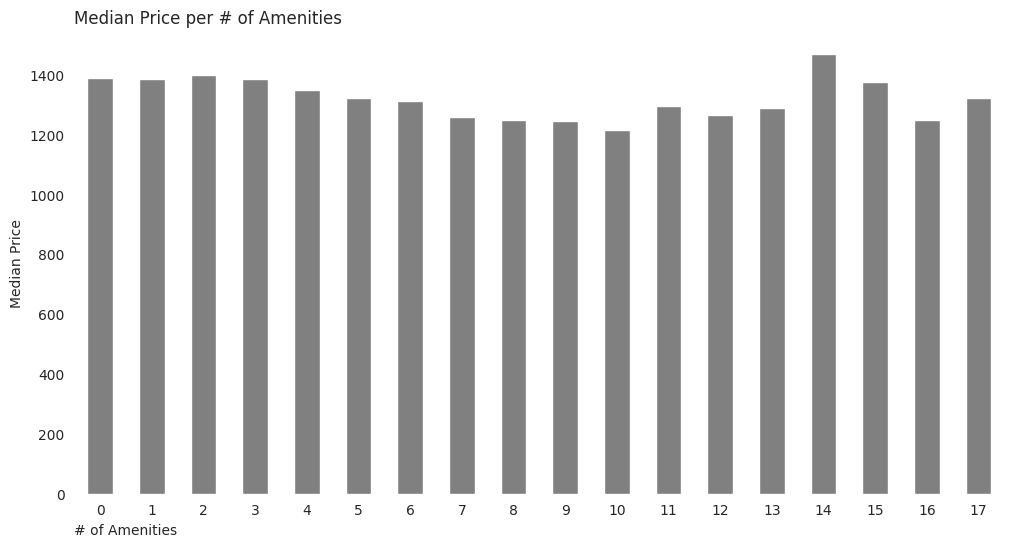

In [56]:
df[[c, 'price']].groupby(c).median().plot.bar(
    figsize=(12, 6),
    color='grey'
)
plt.title('Median Price per # of Amenities', loc='left', fontsize=12)
plt.xlabel('# of Amenities', loc='left', fontsize=10)
plt.ylabel('Median Price', fontsize=10)
plt.legend().remove()
plt.xticks(rotation=0)
plt.box(False)

### Pets
For `pet_allowed`, we see no difference between cats allowed or dogs allowed such that we will consider it as a binary column: if any pet is allowed, we leave it as 1 and 0 otherwise. In this case, we notice that the null values correspond to no pets allowed and thus fill the missing values with 0.

Before starting, however, we observe some entries with the `Cats,Dogs,None` value, and choose to replace it with `Cats,Dogs`. Having done that, we get the column unique values.

In [19]:
df.loc[df['pets_allowed'] == 'Cats,Dogs,None', 'pets_allowed'] = 'Cats,Dogs'

df['pets_allowed'].unique()

array(['Cats', 'Cats,Dogs', nan, 'Dogs'], dtype=object)

We now perform the transformation: fill the missing values with 0 and replace the value by 1 where it is not missing. In this sense, we get the binary column we were interested in.

In [20]:
c = 'pets'
df[c] = df['pets_allowed']\
    .fillna(0)\
    .apply(lambda x: x if x == 0 else 1)

df[c].value_counts()

pets
0    59872
1    38751
Name: count, dtype: int64

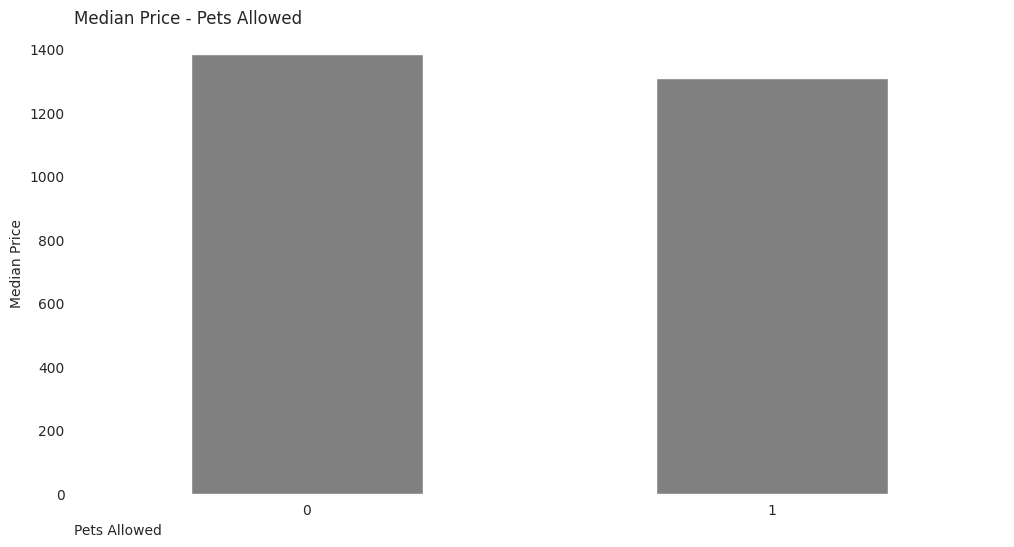

In [40]:
df[[c, 'price']].groupby(c).median().plot.bar(
    figsize=(12, 6),
    color='grey'
)
plt.title('Median Price - Pets Allowed', loc='left', fontsize=12)
plt.xlabel('Pets Allowed', loc='left', fontsize=10)
plt.ylabel('Median Price', fontsize=10)
plt.legend().remove()
plt.xticks(rotation=0)
plt.box(False)

### Square Meters
Similarly for square meters, there are outliers and we treat it with $s = 3$ to consider larger and very small apartments. In the same fashion, we see no distortions from reality or errors, but real cases.

In [21]:
c = 'm2'
q1 = df[c].quantile(.25)
q3 = df[c].quantile(.75)
iqr = q3 - q1

s = 3
l_bound = q1 - s * iqr
u_bound = q3 + s * iqr

print(f'Lower bound: {l_bound}')
print(f'Upper bound: {u_bound}')

sqmt_outliers = (df[c] < l_bound) | (df[c] > u_bound)
df[sqmt_outliers]

Lower bound: -39.390872000000016
Upper bound: 210.98271300000002


,id,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,cityname,state,m2,n_amenities,pets
11,5668637998,NaN,3.0,2.0,NaN,3195.0,3077,Marblehead,MA,285.862531,0,0
13,5668637541,NaN,3.0,4.0,NaN,7800.0,4650,Scottsdale,AZ,431.998950,0,0
42,5668626906,"Dishwasher,Refrigerator",3.0,4.0,NaN,4950.0,3350,Mission Viejo,CA,311.225050,2,0
80,5668637644,NaN,3.0,3.0,NaN,3995.0,2831,Portland,OR,263.008393,0,0
84,5668636001,"Parking,Storage,Washer Dryer",2.0,3.0,NaN,1250.0,2628,Fort Smith,AR,244.149084,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99028,5122227838,NaN,2.0,4.0,NaN,2095.0,2600,Thompsons Station,TN,241.547800,0,0
99168,5122193039,NaN,2.0,3.0,NaN,1995.0,2507,Mount Juliet,TN,232.907821,0,0
99267,5122105468,"Parking,Playground,Pool",3.0,4.0,NaN,2200.0,2292,Miami,FL,212.933676,3,0
99328,5122057036,"Clubhouse,Fireplace,Playground,Pool,Tennis",2.0,4.0,NaN,2000.0,2394,Suwanee,GA,222.409782,5,0


In [22]:
df = df[~sqmt_outliers].copy()

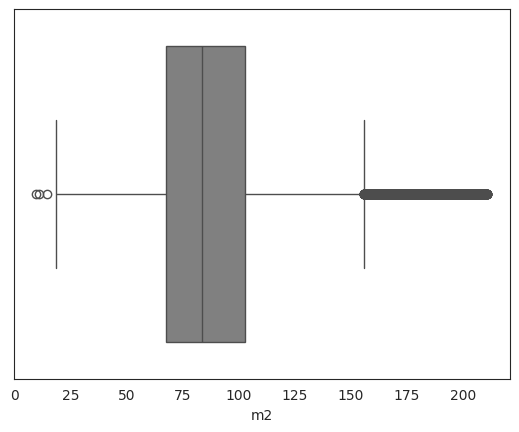

In [43]:
sns.boxplot(
    data=df,
    x=c,
    color='grey'
);

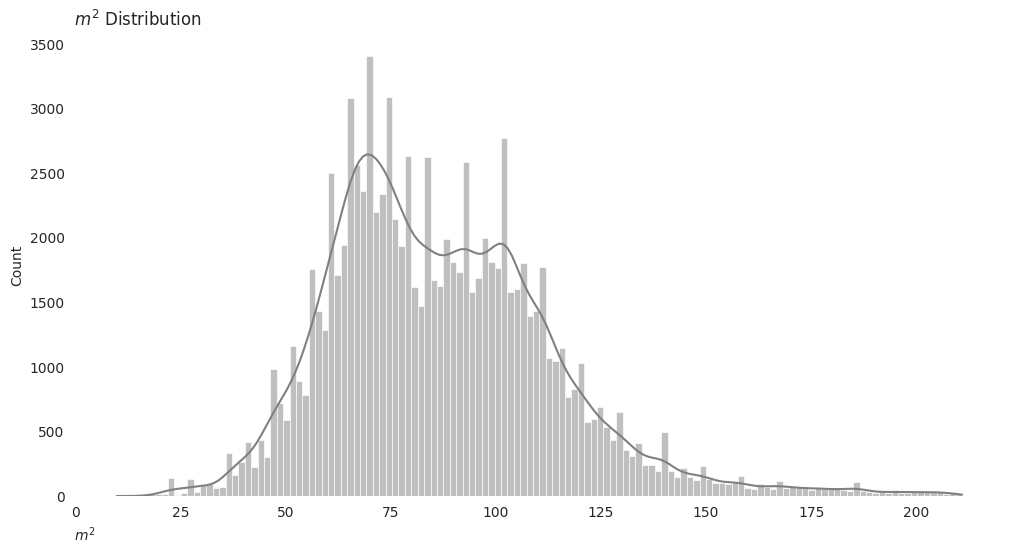

In [44]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x=c,
    color='grey',
    kde=True
)
plt.title('$m^2$ Distribution', loc='left', fontsize=12)
plt.xlabel('$m^2$', loc='left', fontsize=10)
plt.box(False)

Its relation with the target column cannot be seen clearly in the scatterplot below due to outliers in the target, to be treated soon. Regardless, it is expected to see an increase in `prices` with increasing `m2`.

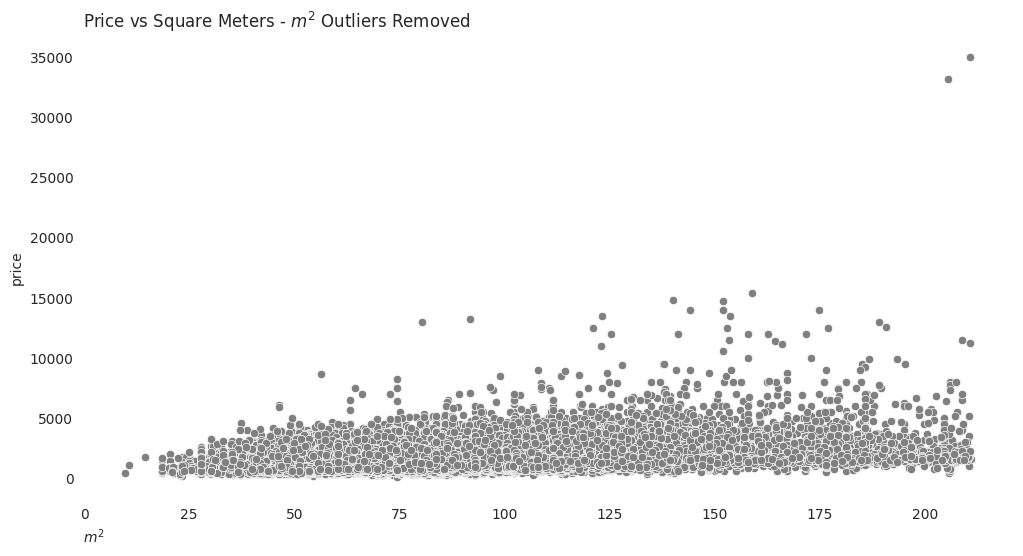

In [45]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x=c,
    y='price',
    color='grey'
)
plt.title('Price vs Square Meters - $m^2$ Outliers Removed', loc='left', fontsize=12)
plt.xlabel('$m^2$', loc='left', fontsize=10)
plt.box(False)

### City Name
We now start a categorical column and we start by dropping its very few null values.

In [46]:
df['cityname'].isnull().sum()

np.int64(297)

In [23]:
df = df[~df['cityname'].isna()].copy()

By checking its cardinality, we observe the high value of 2,921 cities. If we count the number of entries per city, we have Dallas and Denver with nearly 3,000 apartments and Los Angeles with nearly 2,400 as top 3 cities. Further, counting the number of cities with only one apartment, we get 789, being roughly 25% of our dataset.

In [48]:
# cardinality
df['cityname'].nunique()

2921

In [49]:
# counting the number of apartments per city
aux = df['cityname'].value_counts()
aux[:10]

cityname
Dallas         2849
Denver         2728
Los Angeles    2287
Las Vegas      1816
Arlington      1551
Atlanta        1496
Charlotte      1114
Alexandria      911
Richmond        909
Raleigh         863
Name: count, dtype: int64

In [50]:
len(aux[aux == 1])

789

Looking closer to the top 10 cities, we end up with almost 20% of our data. From a dataset with almost 3,000 cities, having 20% of our data in only 10 of them makes us conclude that the dataset is not well distributed with respect to `cityname` and, hence, is biased, in the data distribution sense, towards it.

This impact our prediction reliability, since for frequent cities our predictions will have less variance (more stable) whereas for rare cities it will have high variance (more unstable).

In [51]:
aux[:10].sum()

np.int64(16524)

#### Target Encoder
As `cityname` have a very high cardinality and is a categorical feature, `OneHotEncoding` becomes unfeasible. Another option is to consider *target encoding*: a technique where we replace the `cityname` value by its average price (the target) value. To overcome the difficulty presented by the rare cities (very few entries), we perform a smooth version of the encoder, from the `category_encoder` library.

Caution is advised, however, since the smooth version (also known as regularized) considers a weighted sum between the city mean $\mu_{\text{city}}$ (the mean value at city level) and the global mean $\mu_{\text{global}}$ (the mean value of all cities). If we compute the target encoding at this point, before splitting, information from the test set will leak into the training set, through $\mu_{\text{global}}$, inflating our performance metrics. Likewise, within cross-validation scenarios, we must compute the target encoding inside each individual fold, not globally. We thus leave this technique for later.

In [52]:
df[['cityname', 'price']]\
    .groupby('cityname')\
    .median()\
    .sort_values(by='price', ascending=False)

,price
cityname,
Key Biscayne,7000.0
Del Mar,5495.0
Sag Harbor,5416.0
Great Neck,5380.0
North Waltham,5000.0
...,...
Central City,350.0
Raphine,340.0
Glasco,325.0


#### Is Capital
As another feature we can extract from `cityname`, `is_capital`, as the name suggests, is true when `cityname` is an U.S. capital and false otherwise. To this end, we define a list of all 50 U.S. capitals and apply a `lambda` function to `cityname`.

In [24]:
capitals = [
    'Montgomery', 'Juneau', 'Phoenix', 'Little Rock',
    'Sacramento', 'Denver', 'Hartford', 'Dover',
    'Tallahassee', 'Atlanta', 'Honolulu', 'Boise',
    'Springfield', 'Indianapolis', 'Des Moines', 'Topeka',
    'Frankfort', 'Baton Rouge', 'Augusta', 'Annapolis',
    'Boston', 'Lansing', 'Saint Paul', 'Jackson', 'Jefferson City',
    'Helena', 'Lincoln', 'Carson City', 'Concord', 'Trenton',
    'Santa Fe', 'Albany', 'Raleigh', 'Bismarck', 'Columbus',
    'Oklahoma City', 'Salem', 'Harrisburg', 'Providence',
    'Columbia', 'Pierre', 'Nashville', 'Austin', 'Salt Lake City',
    'Montpelier', 'Richmond', 'Olympia', 'Charleston', 'Madison',
    'Cheyenne'
]

df['is_capital'] = df['cityname'].apply(lambda x: x in capitals).astype(int)

df['is_capital'].value_counts()

is_capital
0    84904
1    12511
Name: count, dtype: int64

We also see am imbalance for this feature, as 87% of the dataset is not in an U.S. capital. Regardless, the average size for apartments in the U.S. capital is slightly smaller than those not in it. The same goes for the mean price value, as expected from the smaller average size.

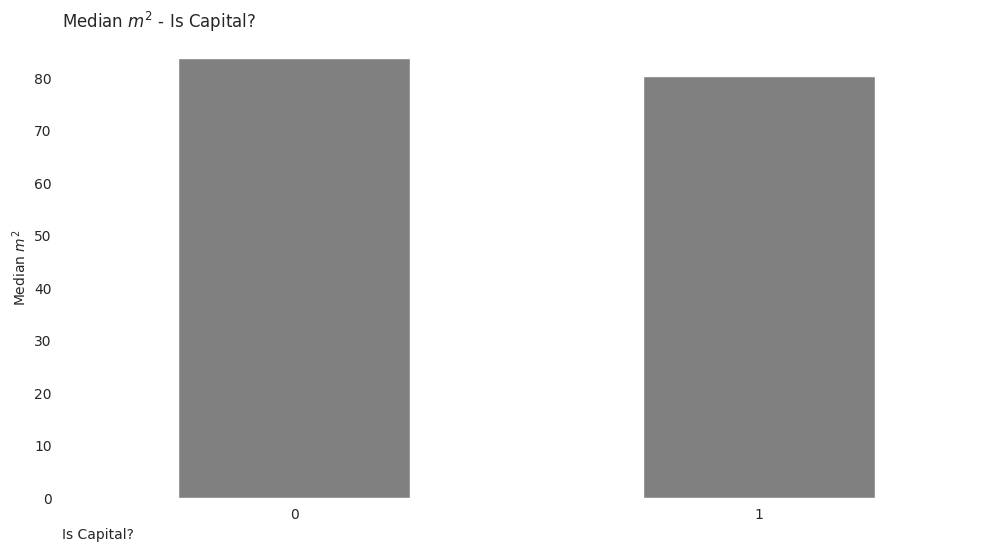

In [54]:
c = 'is_capital'
df[[c, 'm2']].groupby(c).median().plot.bar(
    figsize=(12, 6),
    color='grey'
)
plt.title('Median $m^2$ - Is Capital?', loc='left', fontsize=12)
plt.xlabel('Is Capital?', loc='left', fontsize=10)
plt.ylabel('Median $m^2$', fontsize=10)
plt.legend().remove()
plt.xticks(rotation=0)
plt.box(False)

In [55]:
df[[c, 'price']].groupby(c).agg(['median', 'std'])

price            
            median         std
is_capital                    
0           1350.0  788.368447
1           1322.0  599.692828

### State
Another categorical feature. From the frequency plot below, we observe a sample bias towards the states of Texas and California, followed by Virginia, so that we must apply the regularized version of the target encoder, as well. Shortly after, we plot the most expensive states, by median values.

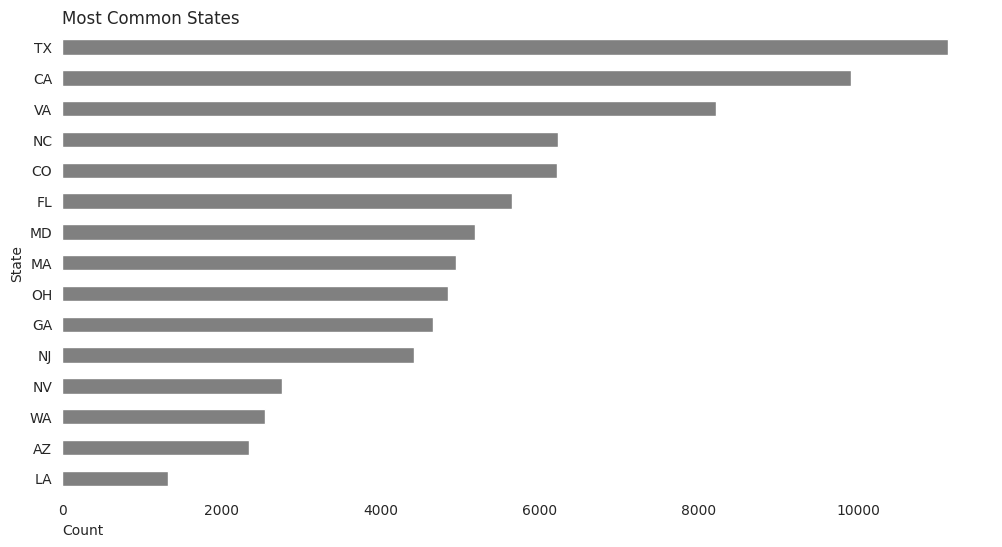

In [56]:
aux = df[['state', 'price']].groupby('state').count()
aux = aux.sort_values(by='price', ascending=False)

aux.head(15)[::-1].plot.barh(
    figsize=(12, 6),
    color='grey'
)
plt.title('Most Common States', loc='left', fontsize=12)
plt.ylabel('State', fontsize=10)
plt.xlabel('Count', loc='left', fontsize=10)
plt.legend().remove()
plt.box(False)

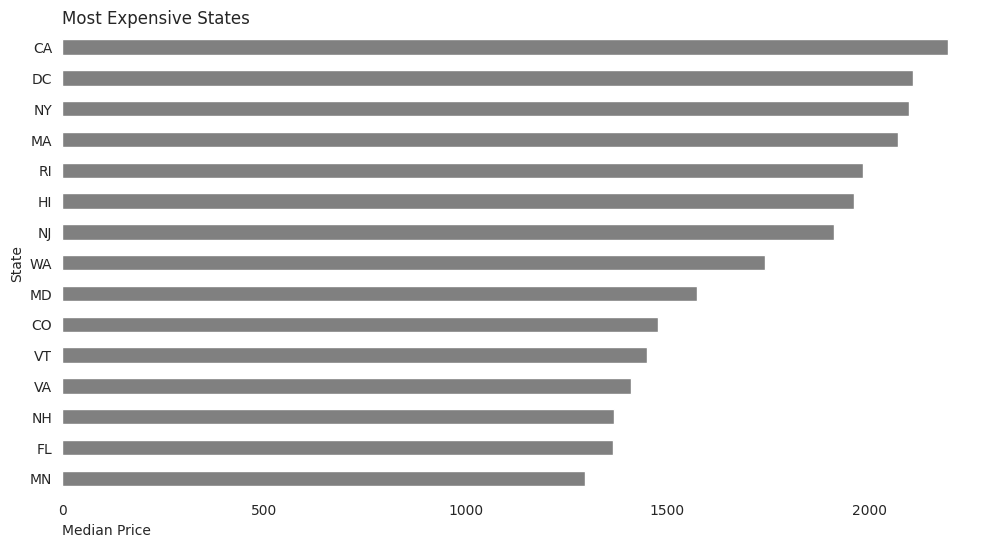

In [57]:
aux = df[['state', 'price']].groupby('state').median()
aux = aux.sort_values(by='price', ascending=False)

aux.head(15)[::-1].plot.barh(
    figsize=(12, 6),
    color='grey'
)
plt.title('Most Expensive States', loc='left', fontsize=12)
plt.ylabel('State', fontsize=10)
plt.xlabel('Median Price', loc='left', fontsize=10)
plt.legend().remove()
plt.box(False)

From the ensuing table, we observe some aggregated metrics as the price's mean, median, and standard deviation. As interesting cases, we highlight CA, HI, and NY, whence we see a very high std value, entailing a very high price dispersion from the most expensive apartments.

In [58]:
df[['state', 'price']].groupby('state').agg(['count', 'mean', 'median', 'std'])

price                                  
       count         mean  median          std
state                                         
AK        54  1048.037037   945.0   296.241612
AL       351   959.179487   840.0   507.366652
AR       591   866.500846   820.0   257.776936
AZ      2346  1109.967604  1085.0   346.258345
CA      9906  2388.549263  2195.0  1184.457009
CO      6219  1546.348448  1478.0   447.995479
CT       508  1264.342520  1190.0   378.795252
DC        73  2277.328767  2110.0   724.587872
DE         7  1154.857143   825.0   581.608525
FL      5653  1531.871042  1365.0   812.163568
GA      4657  1340.168349  1276.0   414.752870
HI        26  2547.692308  1962.5  1745.118031
IA       365   937.846575   875.0   303.827405
ID        93  1103.268817  1005.0   383.594644
IL      1002  1454.369261  1272.5   724.911089
IN       494   970.135628   845.5   462.192526
KS       886   912.314898   833.0   370.061087
KY       982   987.951110   915.0   325.698658
LA      1336  1021.654940   945.0   366.679664
MA      4952  2171.032714  2072.0   712.670914
MD      5187  1634.204935  1574.0   457.922161
ME        30  1260.833333  1250.0   396.260719
MI       691  1161.266281   995.0   548.014147
MN       571  1373.879159  1295.0   482.690444
MO      1185  1042.647257   945.0   432.907587
MS       107   874.158879   825.0   296.905777
MT        85  1082.952941  1095.0   255.834391
NC      6230  1146.806100  1097.0   345.185130
ND       723   923.914246   875.0   299.861659
NE      1017   933.079646   871.0   265.666367
NH       721  1462.292649  1369.0   638.352325
NJ      4421  2037.282063  1914.0   753.994710
NM        24   844.041667   744.5   313.251042
NV      2765  1161.655335  1130.0   339.553853
NY       608  2544.518092  2100.0  1754.290682
OH      4847  1105.561997   978.0   475.339657
OK       921  1003.575461   940.0   336.327275
OR       244  1381.405738  1295.0   415.300451
PA      1104  1294.121377  1183.0   540.760054
RI       114  1960.377193  1985.0   716.076137
SC       898  1132.726058  1075.0   309.075946
SD        84   879.738095   792.5   272.044828
TN      1087  1151.494020  1065.0   436.387909
TX     11123  1211.158500  1135.0   406.314712
UT       788  1282.743655  1195.0   449.021990
VA      8214  1481.765035  1410.0   529.716785
VT       121  1409.752066  1450.0   494.367479
WA      2554  1819.143305  1741.0   535.551337
WI       421  1188.988124  1125.0   444.274853
WV        12   777.750000   707.0   248.802267
WY        16   791.750000   706.5   261.309140

### Price
Our target column. We start by removing the missing value and treating the outliers.

In [29]:
df['price'].isnull().sum()

np.int64(1)

In [25]:
df = df[~df['price'].isna()]

For this column, we consider a less conservative approach, with $s = 2$, due to its tail.

In [26]:
c = 'price'
q1 = df[c].quantile(.25)
q3 = df[c].quantile(.75)
iqr = q3 - q1

s = 2
l_bound = q1 - s * iqr
u_bound = q3 + s * iqr

print(f'Lower bound: {l_bound}')
print(f'Upper bound: {u_bound}')

price_outliers = (df[c] < l_bound) | (df[c] > u_bound)
df[price_outliers]

Lower bound: -526.0
Upper bound: 3314.0


,id,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,cityname,state,m2,n_amenities,pets,is_capital
38,5668627160,"Dishwasher,Parking,Refrigerator",2.0,5.0,NaN,4500.0,2050,Allston,MA,190.451150,3,0,0
39,5668627095,NaN,2.0,3.0,NaN,3990.0,1739,San Jose,CA,161.558317,0,0,0
43,5668626824,NaN,1.0,2.0,"Cats,Dogs",4950.0,1200,Berkeley,CA,111.483600,0,1,0
51,5668624242,"Cable or Satellite,Dishwasher,Fireplace,Parkin...",2.0,4.0,Cats,3580.0,2100,Chicago,IL,195.096300,5,1,0
109,5668626795,NaN,2.0,3.0,"Cats,Dogs",3399.0,1721,San Jose,CA,159.886063,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99469,5121226231,"Gym,Parking,Storage,Wood Floors",1.0,1.0,NaN,4326.0,606,New York,NY,56.299218,4,0,0
99480,5121222729,"AC,Elevator,Parking,Patio/Deck,Pool,Washer Dryer",1.0,1.0,NaN,4495.0,650,New York,NY,60.386950,6,0,0
99485,5121221353,"Dishwasher,Gym,Parking",1.0,1.0,NaN,4395.0,1095,New York,NY,101.728785,3,0,0
104175,5509232542,NaN,1.0,1.0,"Cats,Dogs",3473.0,786,Jersey City,NJ,73.021758,0,1,0


In [27]:
df = df[~price_outliers].copy()

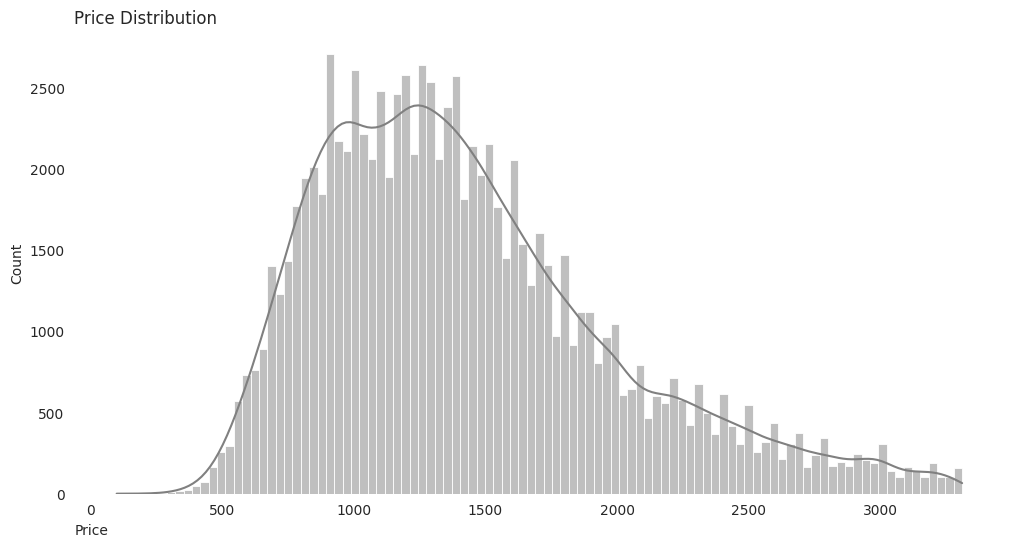

In [63]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='price',
    color='grey',
    kde=True
)
plt.title('Price Distribution', loc='left', fontsize=12)
plt.xlabel('Price', loc='left', fontsize=10)
plt.box(False)

To reduce its skewness, we may apply `np.log1p` on the `price` column to obtain `log_price`, that is $p' = \log(1 + p)$, where $p$ is the price column. For this first version, we train it onto $p$ and, afterwards, onto $p'$.

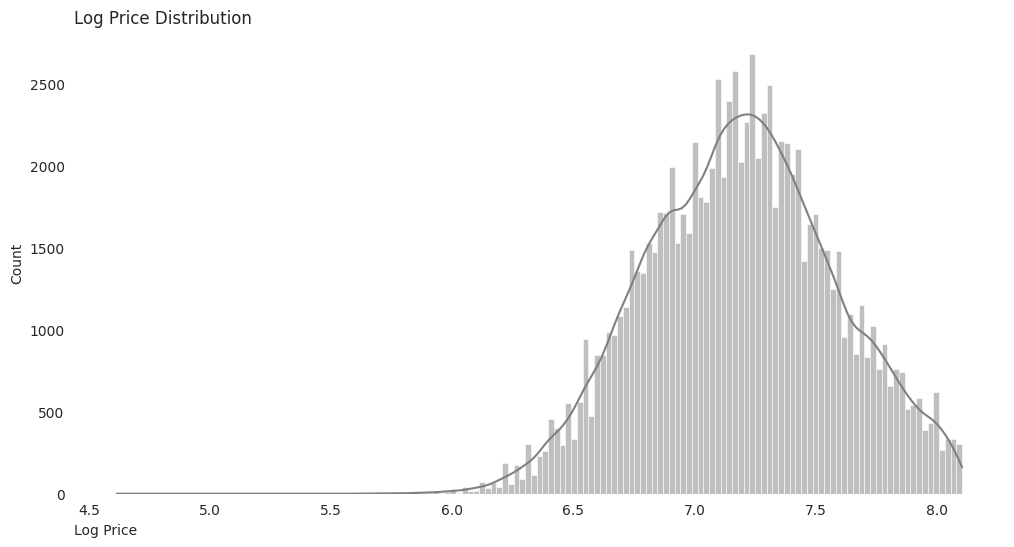

In [28]:
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='log_price',
    color='grey',
    kde=True
)
plt.title('Log Price Distribution', loc='left', fontsize=12)
plt.xlabel('Log Price', loc='left', fontsize=10)
plt.box(False)

We now plot the price column vs $m^2$, with both outliers removed, together with `is_capital`. It is possible to see the expected result: increasing $m^2$ gives rise to increasing prices; but we fail to see linear relation.

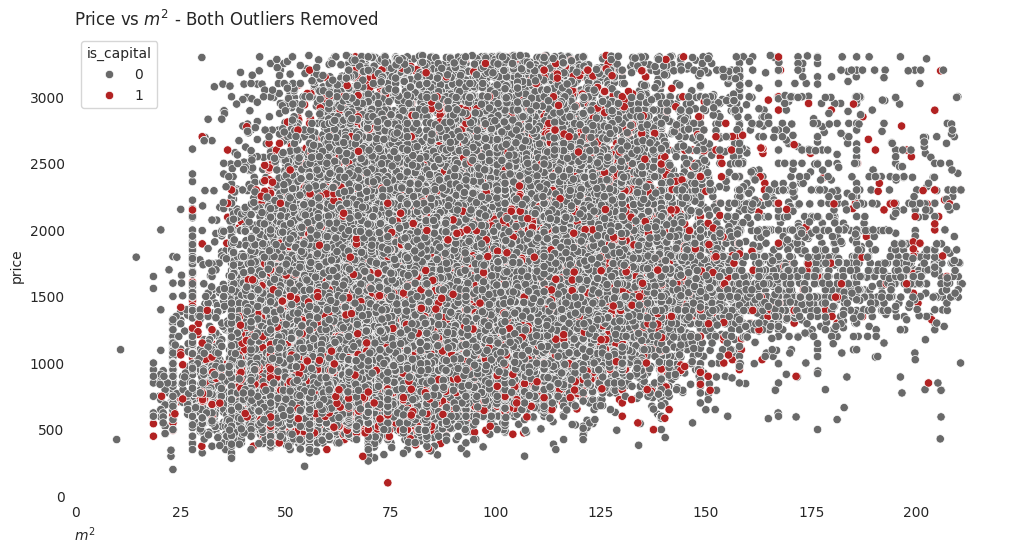

In [35]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='m2',
    y='price',
    palette=['dimgrey', 'firebrick'],
    hue='is_capital'
)
plt.title('Price vs $m^2$ - Both Outliers Removed', loc='left', fontsize=12)
plt.xlabel('$m^2$', loc='left', fontsize=10)
plt.ylim(0)
plt.box(False)

### Final Considerations
Our dataframe, so far, looks like this:

In [120]:
df.head()

,id,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,cityname,state,m2,n_amenities,pets,is_capital,log_price
0,5668640009,NaN,1,1,Cats,2195.0,542,Redondo Beach,CA,50.353426,0,1,0,7.694393
1,5668639818,NaN,1,3,"Cats,Dogs",1250.0,1500,Newport News,VA,139.354500,0,1,0,7.131699
2,5668639686,NaN,2,3,NaN,1395.0,1650,Raleigh,NC,153.289950,0,0,1,7.241366
3,5668639659,NaN,1,2,"Cats,Dogs",1600.0,820,Vacaville,CA,76.180460,0,1,0,7.378384
4,5668639374,NaN,1,1,"Cats,Dogs",975.0,624,Albuquerque,NM,57.971472,0,1,0,6.883463


And we define some variables based on the type of columns we have at our disposal. This will help keep things in order.

In [4]:
# numerical columns
n_cols = [
    'bathrooms', 'bedrooms',
    'n_amenities', 'm2'
]

# boolean columns
b_cols = ['pets', 'is_capital']

# categorical columns
c_cols = ['cityname', 'state']

# by summing them up, we have all our features in a single list
features = n_cols + b_cols + c_cols

# targets: normal and log-transformed
target = ['price']
target_log = ['log_price']

From the `corr()` method, we see no strong linear relation between our features and our target, suggesting that a linear model might not be suited for our task. Moreover, as the highest correlation coefficient is 0.702 for the pair bedrooms x $m^2$, no feature is needed to be discarded for multicolinearity.

In [31]:
df[n_cols + target].corr()

,bathrooms,bedrooms,n_amenities,m2,price
bathrooms,1.000000,0.632391,0.039118,0.688269,0.259206
bedrooms,0.632391,1.000000,-0.029236,0.702483,0.181781
n_amenities,0.039118,-0.029236,1.000000,-0.012619,-0.044154
m2,0.688269,0.702483,-0.012619,1.000000,0.315985
price,0.259206,0.181781,-0.044154,0.315985,1.000000


As good practice, we save our processed dataframe on the `slv_path`, representing the silver layer in the medallion architecture.

In [ ]:
slv_path = 'silver'

In [ ]:
df.to_csv(
    f'{slv_path}/apartments.csv',
    index=False
)

We can thus start fom this point.

In [ ]:
df_slv = pd.read_csv(f'{slv_path}/apartments.csv')

## Modeling
We now start the modeling process. We begin with a simple multivariate LinearRegression model and test several methodologies, such as DecisionTreeRegressor and XGBRegressor.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import root_mean_squared_error
from category_encoders import TargetEncoder
from joblib import dump, load

To our aid, we consider the *Variance Inflation Factor* (VIF) to verify multicolinearity in our dataset, that is, to detect whether two or more features (variables) are highly correlated with each other. In simple terms: it tells us how much redundancy (overlap) of information exists between them. This is especially important in Linear Regression models, since, when features are highly correlated, they carry similar information, such that the model struggles to understand which variable is truly driving the target (one feature might "steal credit" from another). It does not, necessarily, reduce predctive power, but it hurts interpretability and model stability, as coefficients become unstable and sensitive to small data changes.

For the $k$-th feature, $x_k$, we check how well it can be predicted using all other features. If it can be almost perfectly predicted by others, meaning it is redundant, its VIF, $V_k$, will be high. Mathematically, $$V_k = \frac{1}{1 - R_k^2},$$ where $R_k^2$ is the determination coefficient ($R^2$) when regressing $x_k$ against all other features $x_j$, with $j \neq k$. It can thus be used to check which features to keep during modeling.

As a rule of thumb, when $V_k > 5$ we have evidence of strong correlation between $x_k$ and $x_j$, with $j \neq k$, suggesting a further investigation, and when $1 \leq V_k \leq 5$ we have an usually acceptable correlation.

In [8]:
def check_vif(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate Variance Inflation Factor (VIF) for each feature in the input dataframe.
    Returns a dataframe with the features and their corresponding VIF values.
    """
    df_vif = pd.DataFrame()
    df_vif['feature'] = df.columns

    df_vif['VIF'] = [vif(df.values, i) for i in range(df.shape[1])]

    return df_vif

#### Linear Regression - v1

In [55]:
X = df_slv[features].copy()
y = df_slv[target].copy()

In [56]:
SEED = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3 , random_state=SEED)

In [57]:
# target encoder for the categorical columns
enc = TargetEncoder(cols=c_cols)
X_train_enc = enc.fit_transform(X_train, y_train)

# StandardScaler for all, now numerical, variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)

# KNNImputer for all variables
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train_scaled)

# VIF for the training set
check_vif(
    pd.DataFrame(
        data=X_train_imputed,
        columns=features
    )
)

,feature,VIF
0,bathrooms,2.084155
1,bedrooms,2.151984
2,n_amenities,1.100620
3,m2,2.439068
4,pets,1.098022
5,is_capital,1.012051
6,cityname,2.079460
7,state,2.101068


As all of our $V_k$ are within an acceptable limit, we keep all our variables and fit our model as it is.

In [58]:
X_train_ct = sm.add_constant(X_train_imputed)

lr1 = sm.OLS(y_train, X_train_ct).fit()
lr1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                 1.600e+04
Date:                Sat, 25 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:44:02   Log-Likelihood:            -4.7922e+05
No. Observations:               66357   AIC:                         9.585e+05
Df Residuals:                   66348   BIC:                         9.585e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1427.9030      1.286   1110.344      0.000    1425.382    1430.424
x1            83.5406      1.857     44.995      0.000      79.902      87.180
x2           -56.6554      1.887    -30.023      0.000     -60.354     -52.957
x3           -11.7338      1.349     -8.697      0.000     -14.378      -9.089
x4           184.1934      2.008     91.711      0.000     180.257     188.130
x5             4.1457      1.348      3.076      0.002       1.504       6.787
x6            19.5603      1.294     15.119      0.000      17.025      22.096
x7           312.4806      1.854    168.503      0.000     308.846     316.115
x8           137.0656      1.864     73.530      0.000     133.412     140.719
==============================================================================
Omnibus:                     9297.207   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            22081.708
Skew:                           0.815   Prob(JB):                         0.00
Kurtosis:                       5.309   Cond. No.                         2.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We hence obtain a Linear Regression model with a determination coefficient of $R^2 = 0.659$ and the $p$-value for all variables are $\leq 0.05$, being statistically significant. However, from the high Jarque-Bera coefficient value, we have evidence of non-normality for the residual's distribution. Since we have a very large sample size, we will check the normality assumption graphically and by means of the condition mean $\approx$ median $\approx$ mode, such that the equality holds for a normal distribution.

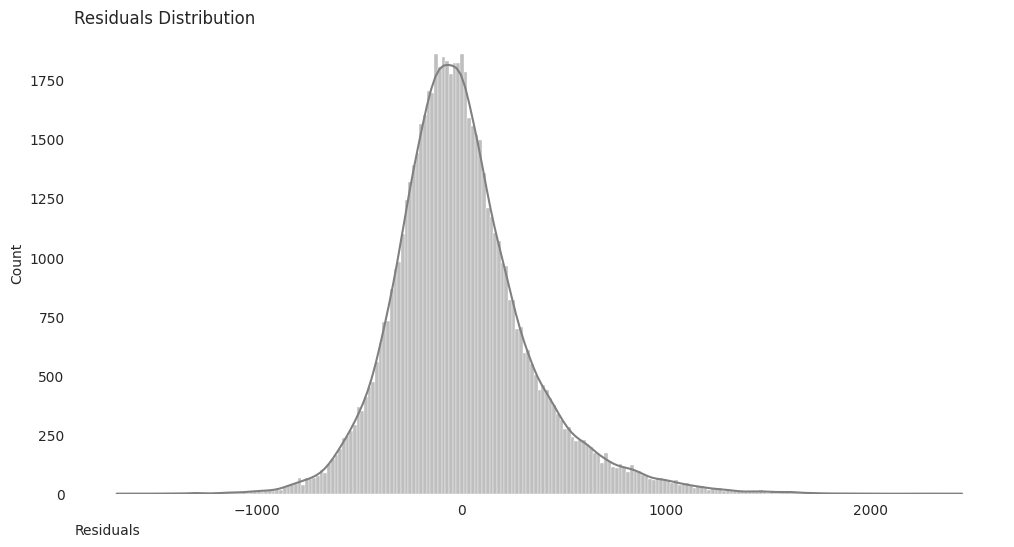

In [74]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=lr1.resid,
    kde=True,
    color='grey'
)
plt.title('Residuals Distribution', loc='left', fontsize=12)
plt.xlabel('Residuals', loc='left', fontsize=10)
plt.box(False)

In [48]:
print(f'Skewness: {lr1.resid.skew():.4f}')
print(f'Kurtosis: {lr1.resid.kurtosis():.4f}')
print(f'Mean: {lr1.resid.mean():.4f}')
print(f'Median: {lr1.resid.median():.4f}')
print(f'Mode: {lr1.resid.mode().iat[0]:.4f}')

Skewness: 0.8147
Kurtosis: 2.3093
Mean: -0.0000
Median: -32.9033
Mode: 421.6991


From the results above we have evidence to conclude that `lr1.resid` is not normally distributed. Being an important assumption for validating Linear Regression models, we can **discard** v1. For comparison, we calculate its RMSE for the test set.

In [59]:
metrics = {}

X_test_enc = enc.transform(X_test)
X_test_scaled = scaler.transform(X_test_enc)
X_test_imputed = imputer.transform(X_test_scaled)
X_test_ct = sm.add_constant(X_test_imputed)
y_pred = lr1.predict(X_test_ct)

metrics['v1'] = root_mean_squared_error(y_test, y_pred)
metrics['v1']

336.5760974186162

In [15]:
model_path = 'models'
dump(lr1, f'{model_path}/lr_v1.pkl')

['models/lr_v1.pkl']

### Linear Regression - v2
For the second version of our Linear Regression, we train it onto `log_price`.

In [16]:
X = df_slv[features].copy()
y = df_slv[target_log].copy()

In [17]:
SEED = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3 , random_state=SEED)

In [ ]:
enc = TargetEncoder(cols=c_cols)
X_train_enc = enc.fit_transform(X_train, y_train)

scaler = StandardScaler()
imputer = KNNImputer(n_neighbors=5)
X_train_scaled = scaler.fit_transform(X_train_enc)

X_train_imputed = imputer.fit_transform(X_train_scaled)

In [19]:
X_train_ct = sm.add_constant(X_train_imputed)

lr2 = sm.OLS(y_train, X_train_ct).fit()
lr2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                 1.572e+04
Date:                Sat, 25 Oct 2025   Prob (F-statistic):               0.00
Time:                        13:55:53   Log-Likelihood:                 3332.0
No. Observations:               66357   AIC:                            -6646.
Df Residuals:                   66348   BIC:                            -6564.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1887      0.001   8046.584      0.000       7.187       7.190
x1             0.0578      0.001     44.814      0.000       0.055       0.060
x2            -0.0409      0.001    -31.156      0.000      -0.043      -0.038
x3            -0.0075      0.001     -8.048      0.000      -0.009      -0.006
x4             0.1349      0.001     96.668      0.000       0.132       0.138
x5             0.0042      0.001      4.519      0.000       0.002       0.006
x6             0.0143      0.001     15.867      0.000       0.012       0.016
x7             0.2014      0.001    153.778      0.000       0.199       0.204
x8             0.1028      0.001     78.107      0.000       0.100       0.105
==============================================================================
Omnibus:                     2063.601   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5454.734
Skew:                           0.077   Prob(JB):                         0.00
Kurtosis:                       4.396   Cond. No.                         3.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

This time, we observe a very a similar $R^2$ from v1 and a much smaller, but yet very high, Jarque-Bera coefficient, suggesting non-normality for the residuals. From the distribution plot and the metrics, however, we notice a tendency of normality. Nevertheless, we have no evidence of linearity from the given dataset, such that a Linear Regression model is not a good model for our case. We thus experiment a DecisionTreeRegressor next.

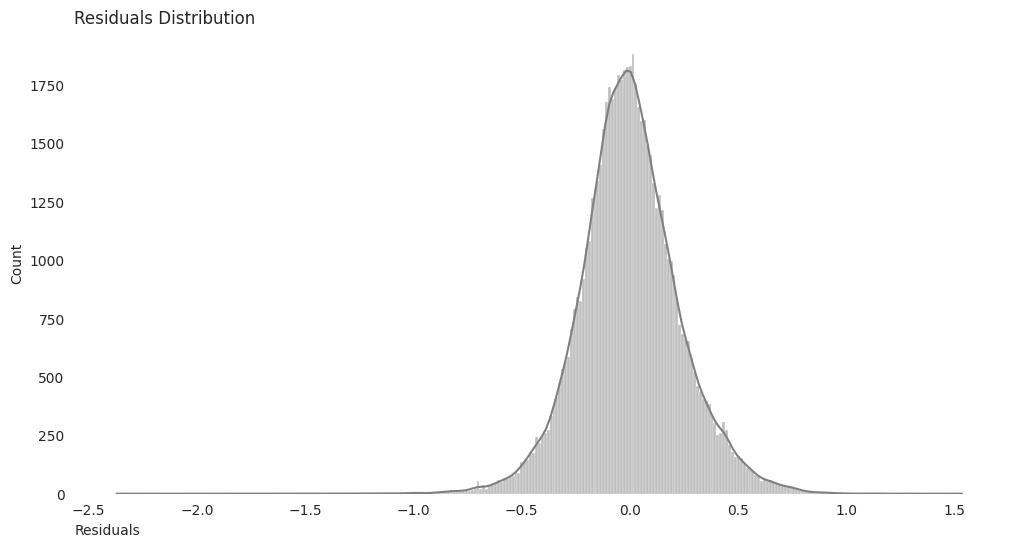

In [52]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=lr2.resid,
    kde=True,
    color='grey'
)
plt.title('Residuals Distribution', loc='left', fontsize=12)
plt.xlabel('Residuals', loc='left', fontsize=10)
plt.box(False)

In [54]:
print(f'Skewness: {lr2.resid.skew():.4f}')
print(f'Kurtosis: {lr2.resid.kurtosis():.4f}')
print(f'Mean: {lr2.resid.mean():.4f}')
print(f'Median: {lr2.resid.median():.4f}')
print(f'Mode: {lr2.resid.mode().iat[0]:.4f}')

Skewness: 0.0765
Kurtosis: 1.3964
Mean: 0.0000
Median: -0.0077
Mode: 0.4286


In [ ]:
X_test_enc = enc.transform(X_test)
X_test_scaled = scaler.transform(X_test_enc)
X_test_imputed = imputer.transform(X_test_scaled)
X_test_ct = sm.add_constant(X_test_imputed)
y_pred = lr2.predict(X_test_ct)


metrics['v2'] = root_mean_squared_error(
    np.expm1(y_test),
    np.expm1(y_pred)
)
metrics['v2']

344.02865279879103

In [21]:
dump(lr2, f'{model_path}/lr_v2.pkl')

['models/lr_v2.pkl']

### Regression Tree with Cross Validation - v3
For this version, we make use of cross validation and `Pipeline` objects.

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
X = df_slv[features].copy()
y = df_slv[target].copy()

# defining the first layer of transformations: TargetEncoder
# for caterigocal columns only, transforming them into numerical ones
pre_encoding = ColumnTransformer(
    transformers=[
        ('encoder', TargetEncoder(cols=c_cols), c_cols),
        ('numerical_pass', 'passthrough', n_cols),
        ('boolean_pass', 'passthrough', b_cols)
    ]
)

# defining the full preprocessing pipeline
# 1. TargetEncoder for categorical columns
# 2. StandardScaler for all numerical columns
# 3. KNNImputer for all columns to fill missing values
preprocessor = Pipeline(
    steps=[
        ('encoder', pre_encoding),
        ('scaler', StandardScaler()),
        ('imputer', KNNImputer(n_neighbors=5))
    ]
)

model_dtr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=SEED))
    ]
)

In [24]:
# cross validation object, shuffling the data
# to ensure randomness in the splits
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

rmse_scores = -cross_val_score(
    model_dtr,
    X, y,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

print(f'Average RMSE: {rmse_scores.mean():.4f}')

Average RMSE: 321.4944


We end up with a smaller RMSE value for the regression tree in comparison with the Linear Regression models.

In [25]:
metrics['v3'] = rmse_scores.mean()
metrics['v3']

np.float64(321.4944125923715)

In [26]:
dump(model_dtr, f'{model_path}/dtr_v1.pkl')

['models/dtr_v1.pkl']

### Regression Tree Optimized - v4
We now show how to implement `GridSearchCV` with the above `Pipeline` and cross validation to see if we can enhance our DecisionTreeRegressor.

In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
X = df_slv[features].copy()
y = df_slv[target].copy()

pre_encoding = ColumnTransformer(
    transformers=[
        ('encoder', TargetEncoder(cols=c_cols), c_cols),
        ('numerical_pass', 'passthrough', n_cols),
        ('boolean_pass', 'passthrough', b_cols)
    ]
)

preprocessor = Pipeline(
    steps=[
        ('encoder', pre_encoding),
        ('scaler', StandardScaler()),
        ('imputer', KNNImputer(n_neighbors=5))
    ]
)

model_dtr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=SEED))
    ]
)

In [29]:
param_grid = {
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 5]
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

grid_search = GridSearchCV(
    estimator=model_dtr,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X, y)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'regressor__max_depth': [None, 5, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('encoder', ...), ('scaler', ...), ...]"


We obtain a RMSE of 293 with `GridSearchCV`, being our smallest error metric so far.

In [25]:
print('Best parameters:', grid_search.best_params_)
print('Best RMSE:', -grid_search.best_score_)

metrics['v3'] = -grid_search.best_score_

Best parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 2}
Best RMSE: 293.1047267772734


From the best estimator object, we are able to plot the feature importances, whence we have the number of bathrooms as our most important feature, followed by `is_capital` and the number of bedrooms, whilst $m^2$ holds the 6th position.

We believe, particularly, we can do better. To this end, we will train a XGBRegressor.

In [30]:
best_dtr = grid_search.best_estimator_
tree = best_dtr.named_steps['regressor']
importances = tree.feature_importances_

importances = pd.Series(
    importances,
    index=features
).sort_values(ascending=True)

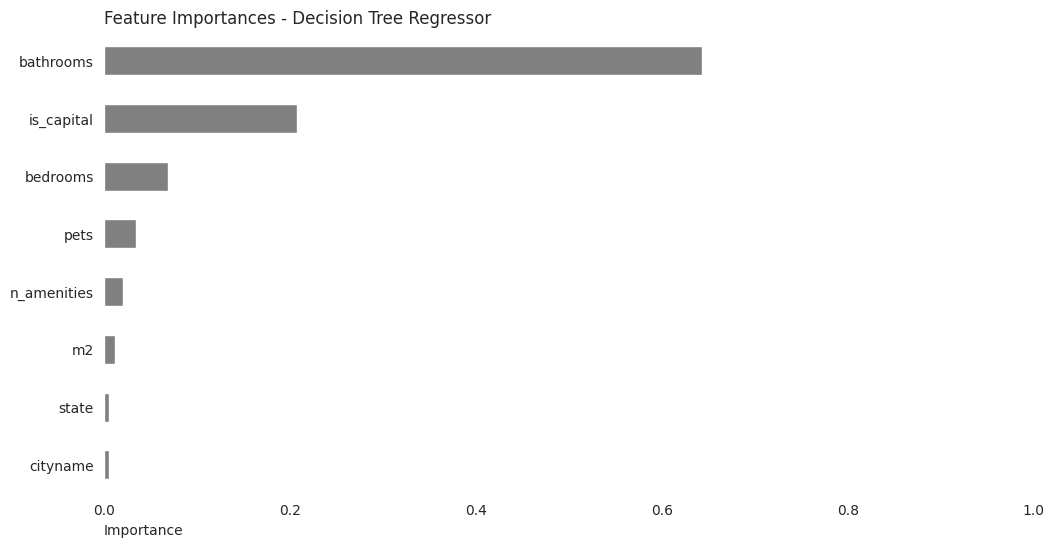

In [65]:
importances.plot.barh(
    figsize=(12, 6),
    color='grey'
)
plt.title('Feature Importances - Decision Tree Regressor', loc='left', fontsize=12)
plt.xlabel('Importance', loc='left', fontsize=10)
plt.xlim(0, 1)
plt.box(False)

In [31]:
dump(best_dtr, f'{model_path}/dtr_v2.pkl')

['models/dtr_v2.pkl']

### XGBRegressor
Here, we execute a XGBRegressor optimized via `GridSearchCV` and cross validation. 

In [26]:
from xgboost import XGBRegressor

In [ ]:
X = df_slv[features].copy()
y = df_slv[target].copy()

pre_encoding = ColumnTransformer(
    transformers=[
        ('encoder', TargetEncoder(cols=c_cols), c_cols),
        ('numerical_pass', 'passthrough', n_cols),
        ('boolean_pass', 'passthrough', b_cols)
    ]
)

preprocessor = Pipeline(
    steps=[
        ('encoder', pre_encoding),
        ('scaler', StandardScaler()),
        ('imputer', KNNImputer(n_neighbors=5))
    ]
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=SEED
)

model_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', xgb)
    ]
)

In [28]:
# 10min
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [.05, .1, .2],
    'regressor__subsample': [.8, 1],
    'regressor__colsample_bytree': [.8, 1]
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

grid_search = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X, y)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'regressor__colsample_bytree': [0.8, 1], 'regressor__learning_rate': [0.05, 0.1, ...], 'regressor__max_depth': [3, 5, ...], 'regressor__n_estimators': [100, 200, ...], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('encoder', ...), ('scaler', ...), ...]"


For the optimized XGBRegressor, we obtain a RMSE of 258, a decrease of 23% from the Linear Regression and 12% from the DecisionTreeRegressor: an improvement from the previous models.

In [29]:
print('Best parameters:', grid_search.best_params_)
print('Best RMSE:', -grid_search.best_score_)

metrics['v4'] = -grid_search.best_score_

Best parameters: {'regressor__colsample_bytree': 1, 'regressor__learning_rate': 0.2, 'regressor__max_depth': 7, 'regressor__n_estimators': 300, 'regressor__subsample': 1}
Best RMSE: 258.20738525390624


For the features, we have `cityname` as the most important one, followed by the number of bathrooms and square meters. We understand this result to make more sense than that of the DecisionTreeRegressor: the apartment location being the more important feature. Number of bathrooms may be popping up due to its strong correlation with square meters, wherein, we understand, the importance truly lies.

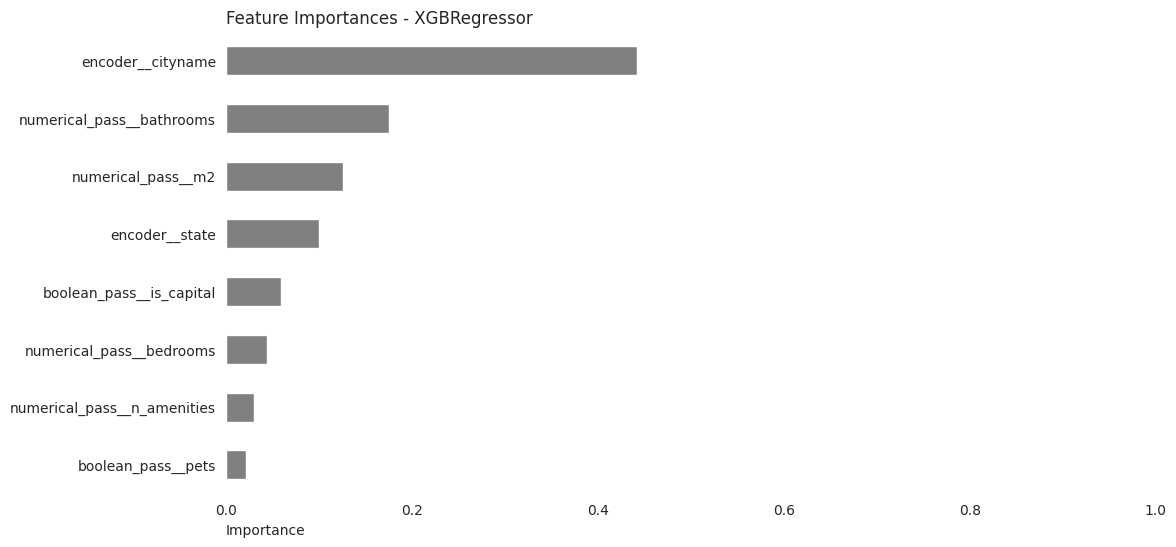

In [30]:
best_xgb = grid_search.best_estimator_
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()
importances = best_xgb.named_steps['regressor'].feature_importances_

importances = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=True)

importances.plot.barh(
    figsize=(12, 6),
    color='grey'
)
plt.title('Feature Importances - XGBRegressor', loc='left', fontsize=12)
plt.xlabel('Importance', loc='left', fontsize=10)
plt.xlim(0, 1)
plt.box(False)

In [ ]:
dump(best_xgb, f'{model_path}/xgb_regressor.pkl')

['models/xgb_regressor.pkl']

## Deploy
In this section we simulate a batch process and establish a reference model, based on our training dataset, to keep track of any deviations while in production. We start by loading the XGBRegressor: the final model.

In [ ]:
xgb = load(f'{model_path}/xgb_regressor.pkl')

Next, we create a deploy function, ensuring that the input contains all necessary features and all of the predictve prices come out right ($\geq$ 0). If not, we set it to 99 as our special floor price. This value is strictly arbitrary and must be set based on the business needs. Our intention is simply to prevent negative prices.

In [ ]:
def deploy(df: pd.DataFrame, regressor, floor_price: float=99.0) -> pd.DataFrame:
    """Deploy rental price predictions on new data using the provided regressor pipeline.

    Args:
        df (pd.DataFrame): New data containing features for prediction.
        regressor (Pipeline): Trained regression pipeline.

    Returns:
        pd.DataFrame: DataFrame with original data and predicted rental prices.
    """
    # ensuring that the input contains all necessary features
    features = [
        'bathrooms', 'bedrooms',
        'n_amenities', 'm2',
        'pets', 'is_capital',
        'cityname', 'state'
    ]

    missing_cols = set(features) - set(df.columns)
    if missing_cols:
        raise ValueError(f'Missing columns in input data: {missing_cols}')

    pred_prices = regressor.predict(df[features])

    # adding the predictions
    price_df = df.copy()
    price_df['pred_price'] = pred_prices

    # checking if all prediction are valid (>= 0)
    if not (price_df['pred_price'] >= 0).all():
        print('Warning: some predicted prices came out negative. Setting them to a minimum value of 99.')
        price_df.loc[price_df['pred_price'] < 0, 'price_df'] = floor_price


    return price_df

In [52]:
new_data = pd.DataFrame({
    'bathrooms': [1, 2, 1],
    'bedrooms': [2, 3, 1],
    'n_amenities': [4, 7, 3],
    'm2': [60, 85, 45],
    'pets': [1, 0, 1],
    'is_capital': [0, 1, 0],
    'cityname': ['Austin', 'New York', 'Tampa'],
    'state': ['TX', 'NY', 'FL']
})
new_data

,bathrooms,bedrooms,n_amenities,m2,pets,is_capital,cityname,state
0,1,2,4,60,1,0,Austin,TX
1,2,3,7,85,0,1,New York,NY
2,1,1,3,45,1,0,Tampa,FL


In [53]:
output = deploy(new_data, xgb)
output

,bathrooms,bedrooms,n_amenities,m2,pets,is_capital,cityname,state,pred_price
0,1,2,4,60,1,0,Austin,TX,990.900208
1,2,3,7,85,0,1,New York,NY,2574.180664
2,1,1,3,45,1,0,Tampa,FL,992.993286


### Reference
As a reference model, we consider all of our training dataset. We can evaluate the price distribution while in production and compare it to the reference price distribution to track model's performance. If, by any reason, we start seeing deviations from the reference distribution, a model retraining might be in order.

In [45]:
baseline = deploy(df_slv, xgb)
baseline

,id,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,cityname,state,m2,n_amenities,pets,is_capital,log_price,pred_price
0,5668640009,NaN,1.0,1.0,Cats,2195.0,542,Redondo Beach,CA,50.353426,0,1,0,7.694393,2236.433105
1,5668639818,NaN,1.0,3.0,"Cats,Dogs",1250.0,1500,Newport News,VA,139.354500,0,1,0,7.131699,1154.144043
2,5668639686,NaN,2.0,3.0,NaN,1395.0,1650,Raleigh,NC,153.289950,0,0,1,7.241366,1625.991333
3,5668639659,NaN,1.0,2.0,"Cats,Dogs",1600.0,820,Vacaville,CA,76.180460,0,1,0,7.378384,1817.451294
4,5668639374,NaN,1.0,1.0,"Cats,Dogs",975.0,624,Albuquerque,NM,57.971472,0,1,0,6.883463,749.730835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94792,5509239203,Parking,2.0,2.0,"Cats,Dogs",2191.0,1144,Princeton,NJ,106.281032,1,1,0,7.692570,2307.953857
94793,5509230921,Washer Dryer,1.0,1.0,NaN,2950.0,1155,Pasadena,CA,107.302965,1,0,0,7.989899,2715.210938
94794,5509240165,NaN,2.0,3.0,NaN,2503.0,1337,Princeton,NJ,124.211311,0,0,0,7.825645,2567.622559
94795,5509233617,"Gym,Parking,Pool,Wood Floors",2.0,3.0,NaN,2229.0,1455,Grapevine,TX,135.173865,4,0,0,7.709757,1896.872559


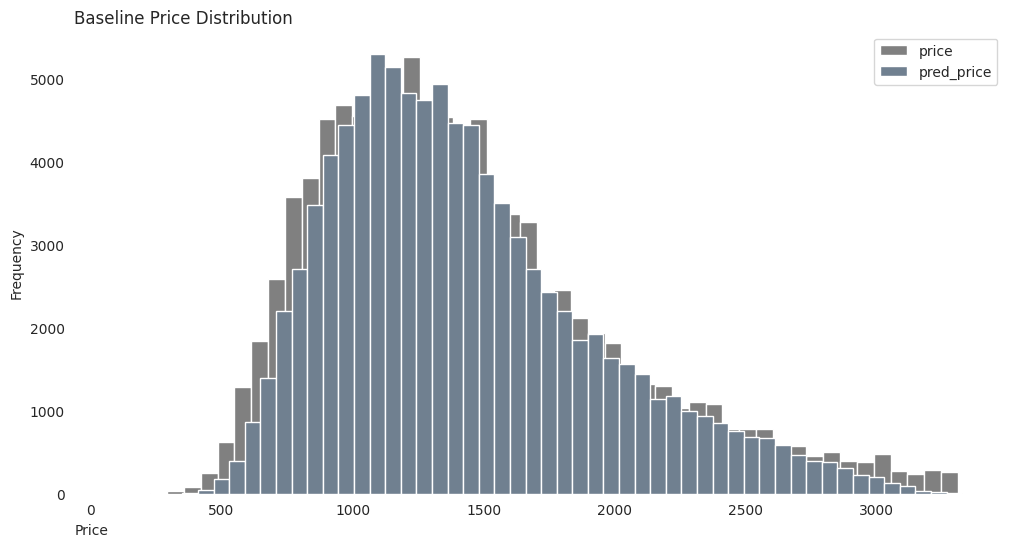

In [63]:
ax = baseline['price'].plot.hist(
    figsize=(12, 6),
    color='grey',
    bins=50,
    legend='Reference'
)
baseline['pred_price'].plot.hist(
    figsize=(12, 6),
    color='slategrey',
    bins=50,
    legend='Predicted',
    ax=ax
)
plt.title('Baseline Price Distribution', loc='left', fontsize=12)
plt.xlabel('Price', loc='left', fontsize=10)
plt.box(False)

## Conclusion
This project explored the prediction of rental apartment prices using data on property characteristics and location. The main goal was to develop a model capable of estimating rental prices, helping both customers and real estate companies, as it can be used to identify over or under priced listings.

The solution followed an end-to-end Machine Learning pipeline approach, including:

1. Data understanding and cleaning
    - prices were put to the same unit and scale
    - removal and treatment of missing values
    - outliers analysis using standard deviation thresholds
2. Feature engineering: creation of features, such as
    - `is_capital` flag to represent state capitals
    - `n_amenities` to consider the number of amenities listed
3. Encoding and scaling
    - we used Target Encoder for categorical variables, ensuring cross-validation safe application to prevent data leakage
    - all features were stardandized for consist scaling
4. Missing data
    - we applied `KNNImputer` to infer missing values based on feature similarity
5. Modeling and validation
    - started with LinearRegression models, but due to the residuals non-normality we later evolved to DecisionTreeRegressor and XGBRegressor, both optimized with GridSearchCV
    - implemented cross-validation to ensure robust performance estimation and prevent overfitting
    - compared model performance to quantify real model gains
    - used RMSE as the main evluation metric, providing interpretable error magnitudes in the same unit as our target variable (price)

Main insights:
- a small number of large cities dominated the dataset, indicating potential sampling bias, a point to be considered for future data collection
- the final solution was an XGBRegressor integrated into a scikit-learn pipeline
- location (`cityname`) proved to be the most influential predictor, validating the strong geographical dependency of rental prices
- a batch inference function was developed to simulate production environment, receiving new data and returning predicted prices

As next steps, we can: **i)** incorporate external data sources, such as neighborhood safety, proximity to transport or socio-economic indicators; and **ii)** monitor real-time model drift and recalibrate predictions as new data is collected.